In [47]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix


In [48]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


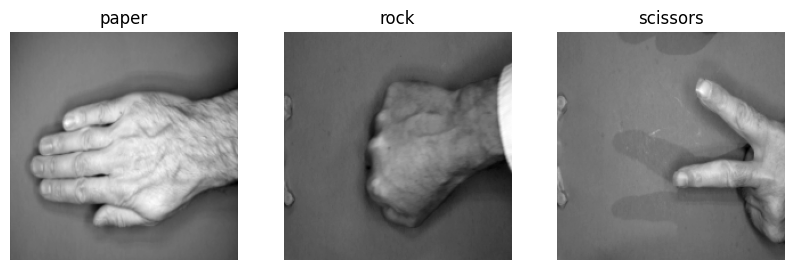

In [49]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [50]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
   
])

In [51]:
model_1 = keras.Sequential(
    [
    #data_augmentation,
    layers.Rescaling(1./255),
    layers.Resizing(96, 96),        
   layers.Conv2D(24, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
    layers.Dense(3,activation='softmax')

    ]
)

/home/loren/miniconda3/envs/StatML/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model_1.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
model_1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4380 - loss: 2.0196 - val_accuracy: 0.6313 - val_loss: 0.8883
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6958 - loss: 0.7391 - val_accuracy: 0.8219 - val_loss: 0.5531
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8564 - loss: 0.4580 - val_accuracy: 0.8188 - val_loss: 0.4656
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9171 - loss: 0.3161 - val_accuracy: 0.9000 - val_loss: 0.3570
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9275 - loss: 0.2553 - val_accuracy: 0.8094 - val_loss: 0.4840
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9484 - loss: 0.2190 - val_accuracy: 0.8750 - val_loss: 0.3456
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9654 - loss: 0.1723 - val_accuracy: 0.8625 - val_loss: 0.3506
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9661 - loss: 0.1480 - val_accuracy: 0.8969 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
Predicted label: scissors
Actual label: scissors


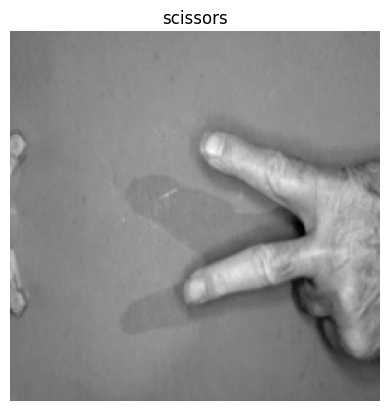

In [55]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [56]:
model_1.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9137 - loss: 0.2694


[0.26940715312957764, 0.913690447807312]

In [57]:
model_2 = keras.Sequential(
    [
        data_augmentation,
    layers.Rescaling(1./255),
   layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal'),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
    layers.Dense(84, activation="relu",kernel_initializer='he_normal'),

    layers.Dense(3,activation='softmax')

    ]
)

In [58]:
model_2.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [60]:
model_2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4393 - loss: 1.7446 - val_accuracy: 0.6344 - val_loss: 0.8581
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6952 - loss: 0.6912 - val_accuracy: 0.7375 - val_loss: 0.5921
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -26399us/step - accuracy: 0.8022 - loss: 0.5006 - val_accuracy: 0.7563 - val_loss: 0.5718
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8649 - loss: 0.3824 - val_accuracy: 0.8687 - val_loss: 0.3814
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8805 - loss: 0.3410 - val_accuracy: 0.9031 - val_loss: 0.2519
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9034 - loss: 0.2705 - val_accuracy: 0.9531 - val_loss: 0.1555
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9295 - loss: 0.1982 - val_accuracy: 0.9563 - val_loss: 0.1293
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9354 - loss: 0.1916 - val_accuracy: 0.940

In [61]:
model_2.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9643 - loss: 0.1392


[0.13916730880737305, 0.9642857313156128]

In [62]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (5, 5), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128, activation="relu",name='dense_1',kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [63]:
model_3.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 196, 196, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 98, 98, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 94, 94, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,579 (6.69 MB)

 Trainable params: 1,752,579 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4523 - loss: 1.0780 - val_accuracy: 0.6531 - val_loss: 0.7226
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6893 - loss: 0.7004 - val_accuracy: 0.8719 - val_loss: 0.4298
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8499 - loss: 0.3788 - val_accuracy: 0.9500 - val_loss: 0.1347
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9125 - loss: 0.2819 - val_accuracy: 0.9500 - val_loss: 0.1480
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9262 - loss: 0.2186 - val_accuracy: 0.9625 - val_loss: 0.1202
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9341 - loss: 0.1973 - val_accuracy: 0.9750 - val_loss: 0.0717
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9471 - loss: 0.1915 - val_accuracy: 0.9688 - val_loss: 0.0939
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9569 - loss: 0.1522 - val_accuracy: 0.9719 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted label: rock
Actual label: rock


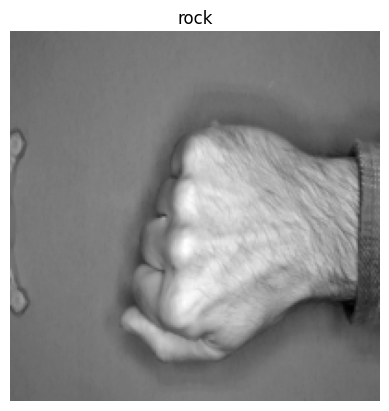

In [65]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [66]:
y_test = []
x_test = []
for batch in test_ds:
    images, labels = batch
    for i in range(len(images)):
        y_test.append(labels[i].numpy())
        x_test.append(images[i].numpy())


In [79]:
y_pred = model_1.predict(tf.convert_to_tensor(x_test))
result=confusion_matrix(y_test, y_pred.argmax(axis=1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [84]:
p=[('Predicted', x)  for x in labels]
b=[('Actual', x)  for x in labels]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
print(df)

                Predicted              
                    paper rock scissors
Actual paper           90    4        3
       rock             4  111        1
       scissors         7    6      110


In [85]:
y_pred = model_2.predict(tf.convert_to_tensor(x_test))
result=confusion_matrix(y_test, y_pred.argmax(axis=1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [86]:
p=[('Predicted', x)  for x in labels]
b=[('Actual', x)  for x in labels]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
print(df)

                Predicted              
                    paper rock scissors
Actual paper           88    2        7
       rock             1  114        1
       scissors         5    0      118


In [89]:
y_pred = model_3.predict(tf.convert_to_tensor(x_test))
result=confusion_matrix(y_test, y_pred.argmax(axis=1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 


In [90]:
p=[('Predicted', x)  for x in labels]
b=[('Actual', x)  for x in labels]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
print(df)

                Predicted              
                    paper rock scissors
Actual paper           89    2        6
       rock             1  113        2
       scissors         0    0      123
